In [3]:
from sklearn.datasets import make_regression

In [2]:
import numpy as np

In [4]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13)

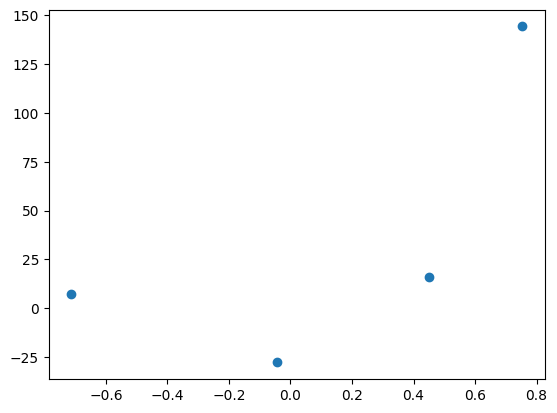

In [6]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

## Lets apply OLS

In [7]:
from sklearn.linear_model import LinearRegression

In [10]:
reg = LinearRegression()
reg.fit(X,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
reg.coef_

array([78.35063668])

In [12]:
reg.intercept_

np.float64(26.15963284313262)

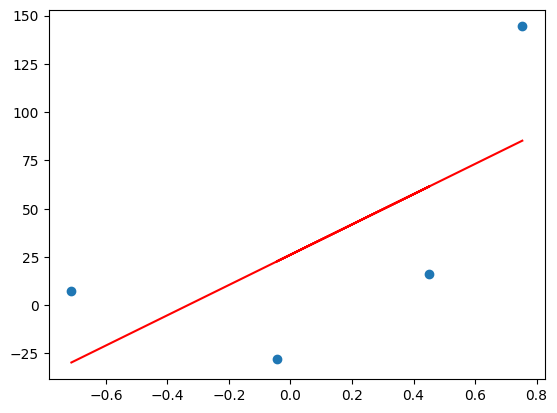

In [13]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X), color='red')

## Lets Apply Gradient Decent

### assume slope to be constant i.e. m = 78.35 
### and lets assume the starting value of intercent is b = 0

In [14]:
y_pred = ((78.35 * X) + 0).reshape(4)

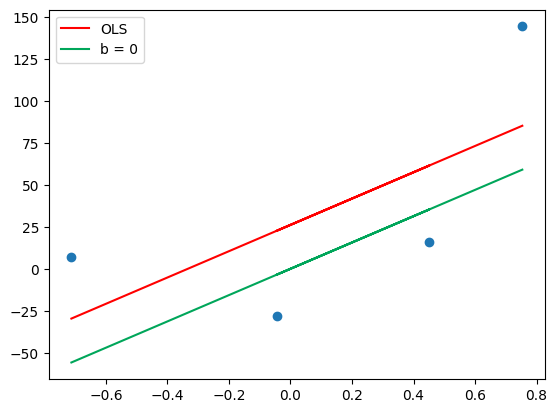

In [19]:
plt.scatter(X,y)
plt.plot(X, reg.predict(X), color = 'red', label='OLS')
plt.plot(X, y_pred, color = '#00a65a', label='b = 0')
plt.legend()
plt.show()

In [25]:
m = 78.35
b = 0
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-209.27763408209216)

In [26]:
# lets take lerning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [27]:
b = b - step_size
b

np.float64(20.927763408209216)

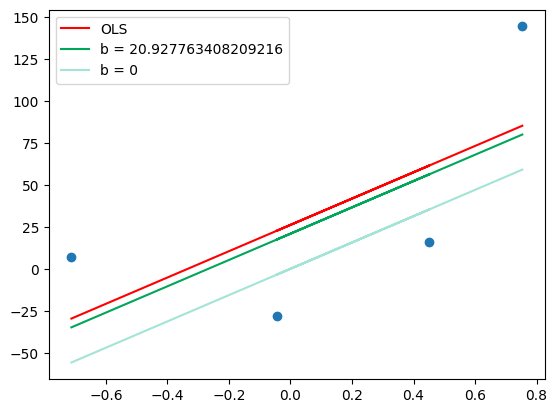

In [30]:
y_pred1 = ((78.35 * X) + b).reshape(4)
plt.scatter(X,y)
plt.plot(X, reg.predict(X), color = 'red', label='OLS')
plt.plot(X, y_pred1, color = '#00a65a', label='b = {}'.format(b))
plt.plot(X, y_pred, color = '#A3E4D7', label='b = 0')
plt.legend()
plt.show()

In [32]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-41.85552681641843)

In [33]:
step_size = loss_slope*lr
step_size

np.float64(-4.185552681641844)

In [34]:
b = b - step_size
b

np.float64(25.11331608985106)

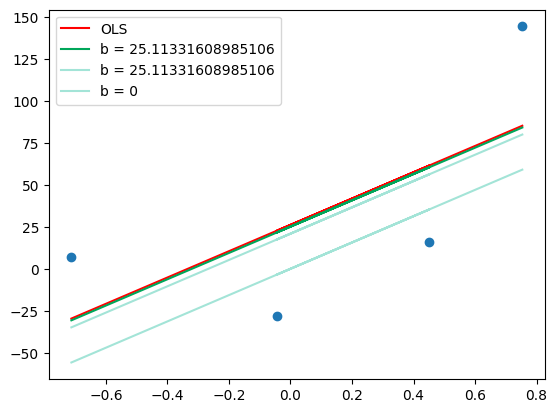

In [36]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X), color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [37]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-8.371105363283675)

In [38]:
step_size = loss_slope*lr
step_size

np.float64(-0.8371105363283675)

In [39]:
b = b - step_size
b

np.float64(25.95042662617943)

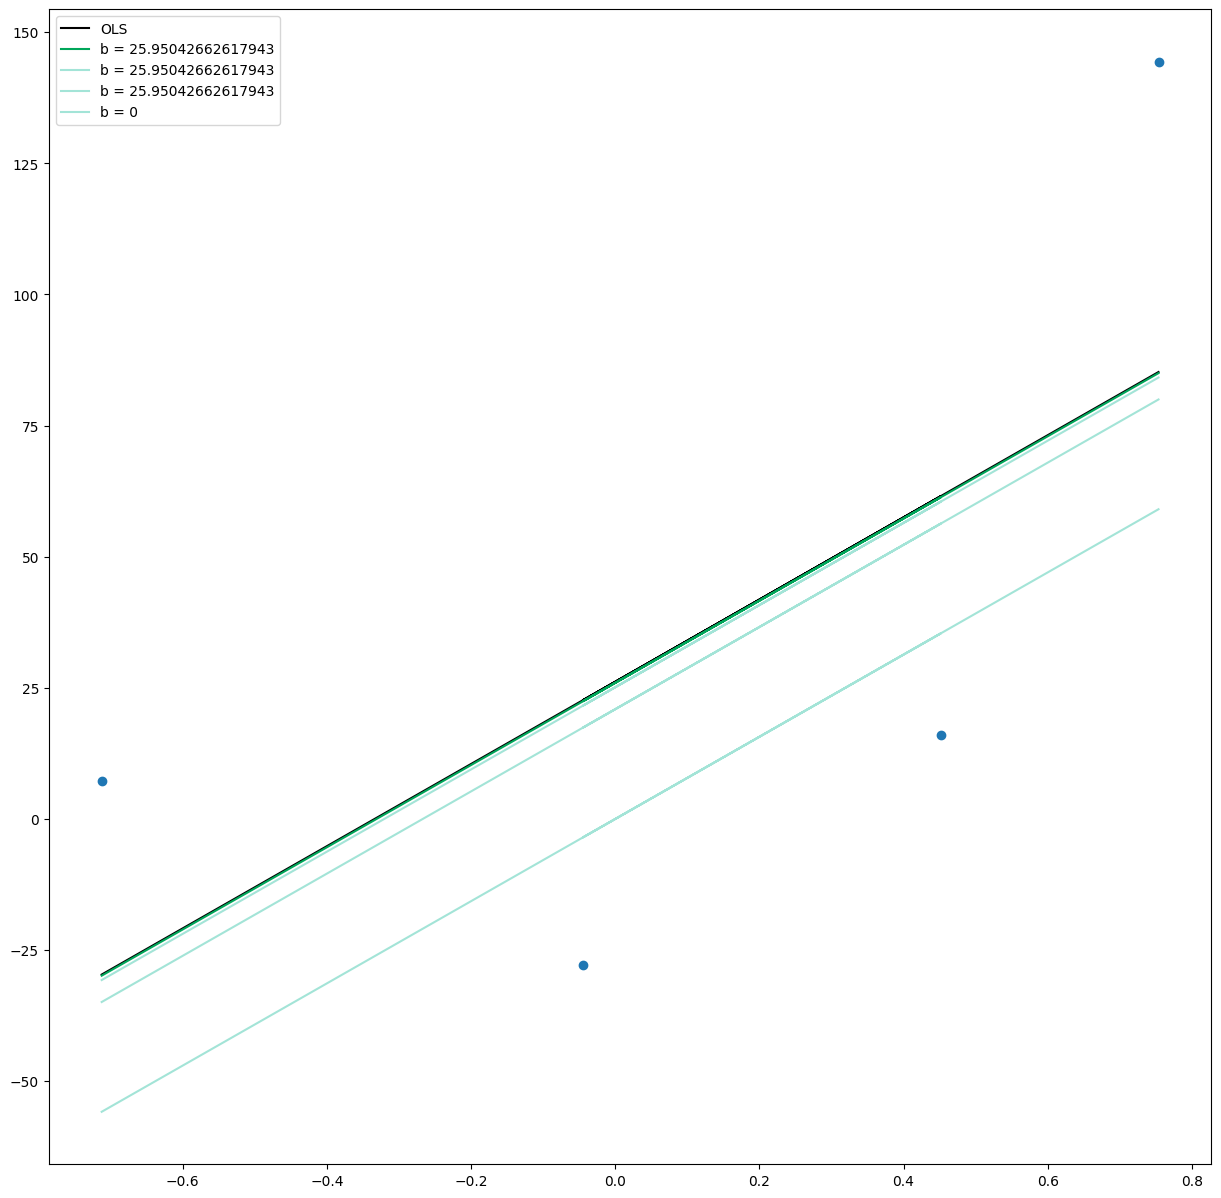

In [41]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X), color='black',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

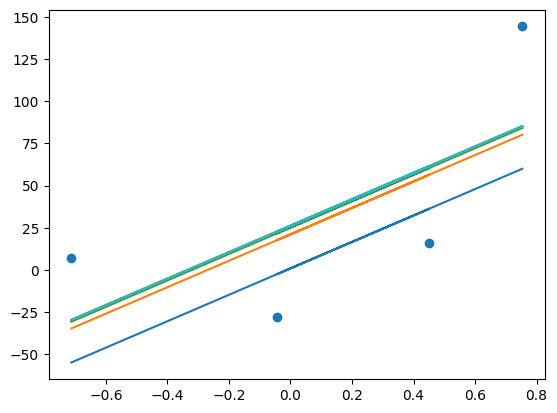

In [43]:
b = -100
m = 78.35
lr = 0.1

epochs = 10

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*X.ravel() - b)
    b = b - (lr * loss_slope)

    y_pred = m * X + b

    plt.plot(X,y_pred)

plt.scatter(X,y)